# Hour 2 · Notebook 0. Setup and Data: EuroSAT for Self-Supervised Learning

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/remote_sensing/00_setup_and_data.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026: *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 2.1. Setting the stage for Hour 2 (slides 30-31)

---

<div class="alert alert-info">

**One principle, three mechanisms.** In Hour 1 we established that self-supervised learning
(SSL) works by defining a *pretext task* whose solution requires learning useful structure
from unlabeled data, and that a *nuisance transformation* (something the representation should
become invariant to, or should be able to undo) is the key design choice separating SSL
families. This notebook sets up the shared playground (dataset, augmentations, and backbone)
that Notebooks 1-3 will each use to instantiate a *different* mechanism (contrastive,
masking, distillation) built on that same principle.

</div>

In this notebook we will:

1. Load **EuroSAT**, a Sentinel-2 satellite image classification dataset, and inspect its 10 classes.
2. Build a fixed, reproducible train/test split (EuroSAT ships no official one).
3. Discuss and implement **remote-sensing-specific data augmentations**. The nuisance
   transformations for this modality, which differ meaningfully from the standard
   augmentation recipe used for natural-image contrastive learning.
4. Instantiate the **ViT-Small/8 backbone** shared by every mechanism notebook that follows.

Let's start with our standard preamble.

In [1]:
## Standard libraries
import os
import urllib.request

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## PyTorch
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`tutorial_rs.py` centralizes plumbing shared across all five notebooks
of this hour (dataset loading, augmentations, the ViT-S/8 backbone, plotting helpers, and the
checkpoint downloader). We fetch it once here if running on Colab.

In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/remote_sensing/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "remote_sensing")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_rs.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_rs.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/remote_sensing/tutorial_rs.py", "tutorial_rs.py")

from tutorial_rs import (
    seed_everything, get_device, setup_plotting, check_colab_gpu, stage_eurosat_locally,
    EUROSAT_CLASSES, EUROSAT_MEAN, EUROSAT_STD, IMG_SIZE,
    load_eurosat, stratified_split,
    ContrastiveTransformations, build_rs_augmentations, build_eval_transform, denormalize,
    build_vit_s8, download_files, show_image_grid,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)
check_colab_gpu(device)

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [3]:
# Path to the folder where the dataset is/should be downloaded
DATASET_PATH = "../../data"
# Path to the folder where pretrained checkpoints are saved
CHECKPOINT_PATH = "../../artifacts/remote_sensing/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial. The dataset itself is
# read from the VM's local disk (Drive only keeps its zip): reading thousands of small files
# through the Drive mount is slow enough to starve the GPU.
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/remote_sensing"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATASET_PATH = stage_eurosat_locally("/content/data", _drive_root + "/data")
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
# Path to precomputed figures/outputs (fallback if this notebook is not executed)
PRECOMPUTED_PATH = "../precomputed"

os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(PRECOMPUTED_PATH, exist_ok=True)

# Colab (Linux) can run the augmentations in background worker processes, which keeps the GPU
# fed; local runs keep the single-process loading the notebooks were tuned with.
NUM_WORKERS = min(4, os.cpu_count() or 1) if "google.colab" in sys.modules else 0

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_vit_s8.pt", "mae_vit_s8.pt", "dino_vit_s8.pt", "random_init_vit_s8.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "remote_sensing", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


<div class="alert alert-info">

**Note:** Notebooks 1-3 each load a checkpoint that was pretrained *offline* on a large
Sentinel-2 corpus (SeCo / BigEarthNet-S2), following the *"Found pretrained model,
loading..."* pattern. If those checkpoints are not yet hosted, each
notebook automatically falls back to a short **live** training run on EuroSAT so that the
mechanism is still fully visible. See the note in each training cell.

</div>

## The EuroSAT dataset

[EuroSAT](https://github.com/phelber/EuroSAT) consists of 27,000 labeled Sentinel-2 patches,
64x64 pixels, covering 10 land-use / land-cover classes: AnnualCrop, Forest,
HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, and
SeaLake. We use the RGB (3-band) version shipped by `torchvision`, a ~90 MB download that
runs comfortably on any Colab instance, keeping the focus of this hour on the SSL *mechanism*
rather than on data engineering.

In [4]:
raw_dataset = load_eurosat(DATASET_PATH, transform=transforms.ToTensor())
print(f"Total images: {len(raw_dataset)}")
print(f"Classes ({len(EUROSAT_CLASSES)}): {EUROSAT_CLASSES}")

targets = np.array(raw_dataset.targets)
for cls_idx, cls_name in enumerate(EUROSAT_CLASSES):
    print(f"  {cls_name:>22s}: {(targets == cls_idx).sum():5d} images")

Total images: 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
              AnnualCrop:  3000 images
                  Forest:  3000 images
    HerbaceousVegetation:  3000 images
                 Highway:  2500 images
              Industrial:  2500 images
                 Pasture:  2000 images
           PermanentCrop:  2500 images
             Residential:  3000 images
                   River:  2500 images
                 SeaLake:  3000 images


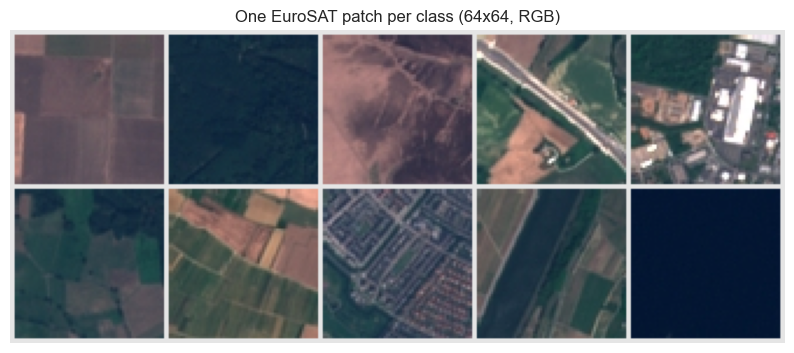

In [5]:
# One example patch per class
seed_everything(42)
example_imgs = []
for cls_idx in range(len(EUROSAT_CLASSES)):
    idx = np.where(targets == cls_idx)[0][0]
    example_imgs.append(raw_dataset[idx][0])
example_imgs = torch.stack(example_imgs, dim=0)

show_image_grid(example_imgs, nrow=5, title="One EuroSAT patch per class (64x64, RGB)")

### A fixed, reproducible split

EuroSAT (as shipped by `torchvision`) has no official train/test split. To keep every
notebook in this hour comparable, and to make the linear-probe comparison in Notebook 4
fair, we fix a **stratified 80/20 split** (`seed=42`) once, in `tutorial_rs.py`, and reuse it
everywhere:

| Stage | Data | Labels used? |
|---|---|---|
| SSL pretraining (live, in Notebooks 1-3) | EuroSAT train split | **no**: discarded, to simulate the "no annotation available" setting |
| Linear probe training | EuroSAT train split | **yes** |
| Evaluation | EuroSAT test split (held out) | **yes** |

In [6]:
train_idx, test_idx = stratified_split(raw_dataset, test_size=0.2, seed=42)
print(f"Train: {len(train_idx)} images | Test: {len(test_idx)} images")

# Sanity check: class balance is preserved in both splits
train_targets = targets[train_idx]
test_targets = targets[test_idx]
for cls_idx, cls_name in enumerate(EUROSAT_CLASSES):
    n_train = (train_targets == cls_idx).sum()
    n_test = (test_targets == cls_idx).sum()
    print(f"  {cls_name:>22s}: train={n_train:4d}  test={n_test:4d}")

Train: 21600 images | Test: 5400 images
              AnnualCrop: train=2400  test= 600
                  Forest: train=2400  test= 600
    HerbaceousVegetation: train=2400  test= 600
                 Highway: train=2000  test= 500
              Industrial: train=2000  test= 500
                 Pasture: train=1600  test= 400
           PermanentCrop: train=2000  test= 500
             Residential: train=2400  test= 600
                   River: train=2000  test= 500
                 SeaLake: train=2400  test= 600


## Remote-sensing augmentations: a different nuisance transformation

<div class="alert alert-info">

This is the key didactic contrast with standard contrastive-learning recipes for natural photos
(e.g., STL10). There, the augmentation recipe encodes assumptions valid for *photographs*: a
photo of a dog is (almost) never seen upside-down, and hue carries little object identity.
Neither assumption holds for **nadir (top-down) satellite imagery**:

- **Rotation and both flips are label-preserving.** A satellite patch has no "up". North-up
  is a cartographic convention, not something the sensor or the scene enforces. So arbitrary
  90°/random rotations, horizontal flips, *and* vertical flips are all valid nuisance
  transformations here, giving stronger geometric invariance than we'd ever apply to natural photos.
- **Color jitter must be mild.** Spectral bands carry physical, radiometric meaning (e.g.
  vegetation indices depend on reflectance ratios). Aggressive color distortion, standard
  in SimCLR's natural-image recipe, would corrupt exactly the signal we want the model to
  preserve, so we apply only gentle brightness/contrast jitter.
- **No perspective/shear.** Satellite patches are already near-orthorectified; the sensor
  never produces the kind of projective distortion that perspective augmentation simulates.

This is a direct instance of the **"transformation → nuisance"** framing from Hour 1: the
augmentation *defines* what the representation is trained to ignore, and that definition is
domain-specific.

</div>

In [7]:
rs_augmentations = build_rs_augmentations(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
print(rs_augmentations)

Compose(
    RandomResizedCrop(size=(64, 64), scale=(0.5, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=warn)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomApply(
    p=0.5
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
)
    RandomApply(
    p=0.5
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
)
    ToTensor()
    Normalize(mean=(0.3444, 0.3803, 0.4078), std=(0.2037, 0.1366, 0.1148))
)


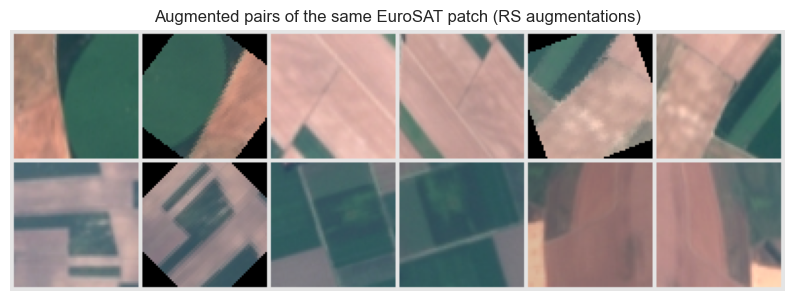

In [8]:
# Visualize augmented pairs: two independent augmentations of the same underlying patch
seed_everything(42)
contrastive_dataset = load_eurosat(
    DATASET_PATH, transform=ContrastiveTransformations(rs_augmentations, n_views=2)
)

NUM_IMAGES = 6
pair_imgs = []
for i in range(NUM_IMAGES):
    idx = train_idx[i]
    views = contrastive_dataset[idx][0]
    pair_imgs.extend([denormalize(v, EUROSAT_MEAN, EUROSAT_STD) for v in views])
pair_imgs = torch.stack(pair_imgs, dim=0)

show_image_grid(pair_imgs, nrow=2 * NUM_IMAGES // 2,
                 title="Augmented pairs of the same EuroSAT patch (RS augmentations)")

Each column pair above comes from the *same* underlying 64x64 patch. Notice how rotation and
flips produce views that look just as physically plausible as the original (unlike a
flipped photo of a building), while the color stays close to the original spectral profile.
This is exactly what the contrastive, masking, and distillation mechanisms in the next three
notebooks will exploit or interact with in different ways.

## The shared backbone: ViT-Small/8

All three mechanism notebooks (contrastive, masking, distillation) train the **same**
architecture: a Vision Transformer, patch size 8, on the native 64x64 EuroSAT resolution.
This gives an 8x8 = 64-token grid.

<div class="alert alert-info">

**Why share one backbone across mechanisms?** Two reasons. First, MAE *requires* a ViT
(patchify + masking is naturally token-based). Second, and more importantly: keeping the
architecture and token budget identical across Notebooks 1-3 is what makes the linear-probe
comparison in Notebook 4 a fair comparison **of the pretraining objective**, rather than a
comparison confounded by different architectures.

</div>

In [9]:
encoder = build_vit_s8().to(device)
n_params = sum(p.numel() for p in encoder.parameters())
print(encoder)
print(f"\nTotal parameters: {n_params / 1e6:.2f}M")
print(f"Patch grid: {encoder.grid_size}x{encoder.grid_size} = {encoder.patch_embed.num_patches} tokens (+1 [CLS])")

ViTEncoder(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=384, out_features=1536, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=1536, out_features=384, bias=True)
        (4): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)

Total parameters: 10.75M
Patch grid: 8x8 = 64 tokens (+1 [CLS])


In [10]:
# Sanity check: a forward pass produces the expected token shape
sample_batch = torch.stack([raw_dataset[i][0] for i in range(4)]).to(device)
sample_batch = (sample_batch - torch.tensor(EUROSAT_MEAN, device=device).view(1, 3, 1, 1)) / \
               torch.tensor(EUROSAT_STD, device=device).view(1, 3, 1, 1)
with torch.no_grad():
    tokens = encoder(sample_batch)
print("Output token shape:", tokens.shape)  # (batch, 1 + num_patches, embed_dim)

Output token shape: torch.Size([4, 65, 384])


## Recap and what comes next

We now have everything the rest of Hour 2 needs:

- **Data**: EuroSAT loaded, a fixed stratified 80/20 split, and RS-specific augmentations
  that encode top-down-view invariances instead of natural-photo invariances.
- **Backbone**: a shared ViT-S/8 encoder (64x64 input → 8x8 token grid, 384-dim embeddings).

Each of the next three notebooks reuses this exact setup and instantiates a *different*
mechanism on top of it:

| Notebook | Mechanism | What differs |
|---|---|---|
| `01_contrastive_simclr.ipynb` | Instance discrimination (InfoNCE) | Two views pulled together, all others pushed apart |
| `02_masking_mae.ipynb` | Masked prediction (MAE) | Reconstruct masked patches, no negatives |
| `03_distillation_dino.ipynb` | Self-distillation (DINO) | EMA teacher-student, no negatives, no reconstruction |

Notebook 4 then puts all three encoders through an identical linear-probe protocol so we can
compare what each mechanism actually learned.

### References

- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). *EuroSAT: A Novel Dataset and Deep
  Learning Benchmark for Land Use and Land Cover Classification.* IEEE JSTARS.
- Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T.,
  Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021).
  *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* ICLR.
- Touvron, H., Cord, M., Douze, M., Massa, F., Sablayrolles, A., & Jégou, H. (2021).
  *Training Data-Efficient Image Transformers & Distillation Through Attention.* ICML.